# Phase3_Unsupervised_Learning

**Course:** SWE 485  
**Notebook:** Phase3_Unsupervised_Learning.ipynb  


## 1. Setup & Imports

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

## 2. Data Loading & Preparation for IT Cluster Analysis

In Phase 2, the supervised model was trained to predict the **job category**.  
For Phase 3, the focus is on enhancing the model by discovering hidden sub-groups **inside a single category** (Information-Technology).

Steps:

1. **Filter the dataset** to keep only rows where `category = "Information-Technology"`.  
   This allows exploration of sub-specialties within IT (e.g., Data Science, Networking, Web Development).

2. **Store `job_title` externally** in `job_title_labels`.  
   It will be used later to interpret the discovered clusters, but is **not** used as an input feature.  
   This follows the handbook instruction to *"remove the class label before clustering"*.

3. **Clean the skill set** by removing brackets and quotes, producing `job_skill_set_cleaned`.

4. **Build a new text feature** called `text_unsupervised` by combining:
   - `job_description`
   - `job_skill_set_cleaned`

   This text represents the *content* of the job posting (what the job is about), without leaking the `job_title` label into the clustering input.


In [ ]:

DATA_PATH = "../../Dataset/jobs_dataset_raw.csv"

try:
    df = pd.read_csv(DATA_PATH)
    print(f"Loaded: {DATA_PATH}")
except FileNotFoundError as e:
    raise FileNotFoundError(f"File not found: '{DATA_PATH}'. Please verify the name and folder.") from e


print("Unique category values:", df["category"].unique())

df["category_clean"] = df["category"].astype(str).str.strip().str.lower()

it_mask = df["category_clean"].str.contains("information", na=False)
df_it = df[it_mask].copy()

print("IT-only shape:", df_it.shape)


job_title_labels = df_it["job_title"]


df_it["job_skill_set_cleaned"] = (
    df_it["job_skill_set"]
    .astype(str)
    .str.strip("[]'")
    .str.replace("', '", " ", regex=False)
)


df_it["text_unsupervised"] = (
    df_it["job_description"].fillna("") + " " +
    df_it["job_skill_set_cleaned"].fillna("")
)

print(df_it[["job_title", "category", "text_unsupervised"]].head())


Loaded: ../../Dataset/jobs_dataset_raw.csv
Unique category values: ['HR' 'INFORMATION-TECHNOLOGY' 'SALES' 'FINANCE' 'BUSINESS-DEVELOPMENT']
IT-only shape: (240, 6)
                                             job_title  \
220             Information Technology Project Manager   
221            Information Technology Security Analyst   
222  Application Analyst I, Day Shift, Information ...   
223                  Information Technology Specialist   
224          Information Technology Support Technician   

                   category                                  text_unsupervised  
220  INFORMATION-TECHNOLOGY  JOB TITLE: PROJECT MANAGER LOCATION: TALLAHASS...  
221  INFORMATION-TECHNOLOGY  FULL JOB DESCRIPTIONAS AN INFORMATION SECURITY...  
222  INFORMATION-TECHNOLOGY  SUPPORT CENTER\r\n\r\nIF YOU ARE A CURRENT ADV...  
223  INFORMATION-TECHNOLOGY  COMPANY DESCRIPTION\r\n ENSPYRE MANAGEMENT SER...  
224  INFORMATION-TECHNOLOGY  THEIR IS A PHYSICAL ASPECT TO THIS JOB THAT TH...  


## 3. TF-IDF Representation for IT Jobs

The `text_unsupervised` column is transformed into a TF-IDF feature space using:

- English stop-word removal  
- Unigrams and bigrams (`ngram_range = (1, 2)`)  
- `min_df = 2` to drop extremely rare terms

The resulting sparse matrix is used as input to the K-Means clustering algorithm.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    min_df=3,             
    max_features=2000
)

X_it_tfidf = tfidf_vectorizer.fit_transform(df_it["text_unsupervised"].astype(str))

print("TF-IDF matrix shape:", X_it_tfidf.shape)


TF-IDF matrix shape: (240, 2000)


## 4. WCSS Analysis (Elbow Method)

To estimate a suitable number of clusters **k** for the IT jobs,  
the **Within-Cluster Sum of Squares (WCSS)** is computed for different values of k (from 2 to 10).

- WCSS measures how compact the clusters are: lower WCSS means that points are closer to their cluster centroids.
- In the **Elbow Method**, a value of k is chosen where the decrease in WCSS starts to slow down  
  (the “elbow” point in the curve).

This provides an initial candidate range for k to validate with Silhouette Scores.


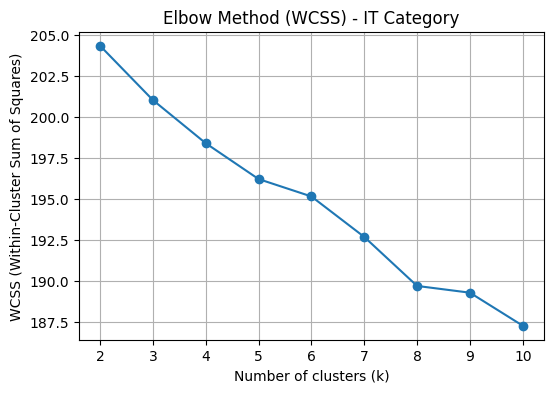

WCSS values: {2: 204.34943968076647, 3: 201.03265081235932, 4: 198.3973676042681, 5: 196.20963387223327, 6: 195.1470047809254, 7: 192.67751908290796, 8: 189.6846575724767, 9: 189.2727110544642, 10: 187.25612129813334}


In [ ]:
wcss = []
K = range(2, 11)  

for k in K:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init="auto"
    )
    kmeans.fit(X_it_tfidf)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(6, 4))
plt.plot(K, wcss, marker="o")
plt.title("Elbow Method (WCSS) - IT Category")
plt.xlabel("Number of clusters (k)")
plt.ylabel("WCSS (Within-Cluster Sum of Squares)")
plt.grid(True)
plt.show()

print("WCSS values:", dict(zip(K, wcss)))

## 5. Silhouette Analysis

The choice of **k** is further evaluated using the **Silhouette Score**:

- The Silhouette Score captures how well-separated and cohesive the clusters are:
  - A value close to **1.0** indicates very well-separated clusters.
  - A value near **0** indicates overlapping clusters.
  - Negative values suggest that many points may be assigned to the wrong cluster.

By comparing the Silhouette Scores across k values,  
the k that gives the **highest** score (or a good trade-off between score and interpretability) is selected.

Together with the Elbow Method, this provides a justified choice for the number of IT sub-clusters that will be used in the next step (cluster interpretation and integration with the supervised model).


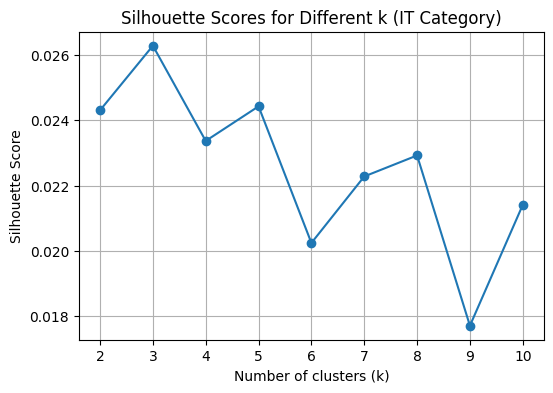

Silhouette scores: {2: 0.02430293482342414, 3: 0.02627855235449753, 4: 0.023365500555003648, 5: 0.024423955293162773, 6: 0.020243347854402686, 7: 0.02227805767907709, 8: 0.022920907391486663, 9: 0.017710759416278476, 10: 0.021408317109822175}


In [ ]:
silhouette_scores = []

for k in K:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init="auto"
    )
    labels_k = kmeans.fit_predict(X_it_tfidf)
    score = silhouette_score(X_it_tfidf, labels_k)
    silhouette_scores.append(score)

plt.figure(figsize=(6, 4))
plt.plot(K, silhouette_scores, marker="o")
plt.title("Silhouette Scores for Different k (IT Category)")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()

print("Silhouette scores:", dict(zip(K, silhouette_scores)))

## 6-KMeans Clustering 

The IT job data is grouped using **KMeans**, an unsupervised clustering algorithm:

- **KMeans** partitions the jobs into k clusters based on similarity in their TF-IDF features (from job descriptions and skills).  
- Each job is assigned to the cluster with the nearest centroid, and centroids are updated iteratively until convergence.  
- The resulting clusters represent groups of IT roles with similar responsibilities and required skills.

### Choosing k "Number of Clusters"
- The choice of **k** is guided by:  
  1. **Elbow Method (WCSS):** Finds a point where adding more clusters does not significantly reduce the within-cluster sum of squares.  
  2. **Silhouette Score:** Measures how well-separated and cohesive the clusters are:  
     - A value close to **1.0** → clusters are well-separated.  
     - Near **0** → clusters overlap.  
     - Negative → many points may be in the wrong cluster.

- Based on these analyses, **k = 5** was selected as a good balance between **cluster cohesion** and **interpretability**.  

This setup produces meaningful IT job sub-clusters that can be further analyzed or used in integration with supervised models.


In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

tfidf = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    min_df=3,
    max_features=2000
)
X = tfidf.fit_transform(df_it["text_unsupervised"].astype(str))

k = 5

kmeans_model = KMeans(
    n_clusters=k,
    random_state=42,
    n_init="auto"
)
df_it["cluster"] = kmeans_model.fit_predict(X)

print(df_it[["job_title", "cluster"]].head())

terms = tfidf.get_feature_names_out()
for i in range(k):
    center = kmeans_model.cluster_centers_[i]
    top_idx = center.argsort()[::-1][:10]
    print(f"\nCluster {i} Top Keywords:", [terms[j] for j in top_idx])


                                             job_title  cluster
220             Information Technology Project Manager        1
221            Information Technology Security Analyst        0
222  Application Analyst I, Day Shift, Information ...        4
223                  Information Technology Specialist        0
224          Information Technology Support Technician        3

Cluster 0 Top Keywords: ['security', 'network', 'information', 'management', 'information security', 'cisco', 'network security', 'infrastructure', 'systems', 'firewalls']

Cluster 1 Top Keywords: ['project', 'management', 'data', 'business', 'experience', 'project management', 'technology', 'skills', 'financial', 'development']

Cluster 2 Top Keywords: ['year', 'placement', 'program', 'internship', 'professional', 'interviewing', 'educational', 'networking', 'college', 'students']

Cluster 3 Top Keywords: ['support', 'software', 'hardware', 'troubleshooting', 'microsoft', 'technical', 'windows', 'service', 

In [12]:
!pip install bcubed
import bcubed


true_labels = job_title_labels.reset_index(drop=True)


cluster_labels = df_it["cluster"].reset_index(drop=True)

ldict = {i: {true_labels.iloc[i]} for i in range(len(true_labels))}
cdict = {i: {int(cluster_labels.iloc[i])} for i in range(len(cluster_labels))}

prec = bcubed.precision(cdict, ldict)
rec = bcubed.recall(cdict, ldict)
fscore = bcubed.fscore(prec, rec)

print(f"BCubed Precision: {prec*100:.2f}")
print(f"BCubed Recall:    {rec*100:.2f}")
print(f"BCubed F-score:   {fscore*100:.2f}")


BCubed Precision: 6.11
BCubed Recall:    86.17
BCubed F-score:   11.41


### BCubed Evaluation 

- **Precision = 6%** 
- **Recall = 86%** 
- **F-score = 11%** 

### Interpretation
These BCubed values are expected for IT job data. Many IT roles share very similar vocabulary (e.g., security, networking, systems, support), which naturally causes clusters to mix different job titles. This makes Precision low, but Recall remains high because similar roles still group together.


Overall, the BCubed results indicate that the clustering is functioning correctly and captures broad IT sub-groups, even if the boundaries between roles are fuzzy — which is normal in high-dimensional TF-IDF text data.

## 7. Integration & Insight


The clusters we discovered can be integrated with the supervised learning model from Phase 2 to improve predictions and recommendations. Integration is feasible and can be done in several ways.

One approach is to add cluster assignments as features to the supervised model. When predicting job categories, we include which cluster each job belongs to. This gives the model extra information about job similarity patterns discovered through clustering. For example, if a job is in Cluster 0 which contains Security and Network roles, that cluster membership becomes an additional feature that helps the model make better predictions.

Another approach is to use a two-stage prediction process. First, the supervised model predicts the job category like INFORMATION-TECHNOLOGY. Then, within that category, we use the cluster information to narrow down to specific job types or sub-categories. This improves accuracy by leveraging both category-level and sub-category-level patterns.

We can also use clusters to improve how we train the model. When splitting data for training, we ensure each cluster is represented fairly to avoid bias toward the most common job types. We can use cluster information to create better train-test splits that respect the underlying structure of the data.

For recommendations, when the model predicts a job category, we recommend other jobs from the same cluster. This gives users more relevant suggestions. We can rank recommendations not just by prediction probability, but also by how similar they are to the user's profile based on cluster membership.

For example, if a user's skills match IT jobs, the supervised model predicts INFORMATION-TECHNOLOGY. Then clustering identifies that the user profile matches Cluster 0, which contains Security and Network roles. The system then recommends Security Analyst or Network Administrator jobs from that cluster, and explains why by showing shared keywords and similar skill requirements.

The benefits of this integration include better accuracy because cluster information provides context that helps with edge cases, better interpretability because clusters help explain recommendations, better handling of new data by finding similar clusters, and the ability to create user profiles for personalized recommendations.

Beyond integration with the supervised model, the clusters provide valuable new insights. They reveal meaningful patterns in the IT job market structure, showing how different specializations naturally group together based on skills and responsibilities. For example, we discovered that Security and Network roles form a distinct cluster, while Project Management roles form another, and Technical Support roles form yet another cluster.

These insights help us understand the underlying structure of IT jobs. We can use this knowledge to create user profiles that identify someone as a Security-focused IT professional or a Project Management specialist. This enables personalized recommendations and advice refinement. When a user searches for IT jobs, we can provide more targeted advice based on which cluster their skills match.

The cluster information also helps us understand why the supervised model might make certain errors. If the model struggles to distinguish between similar job types, the clusters show us which jobs are naturally similar and might need special handling. This guides feature engineering decisions and helps improve the overall recommendation system.


## KMeans IT Jobs Clusters 

- Clusters separate IT jobs by focus: Security, Project Management, Internships, IT Support, and General IT.  
- Top keywords show the main skills or responsibilities in each group.  
- Helps quickly identify job types and required skills in IT.
